In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load csv
df = pd.read_csv("CycleCount_Project.csv")

In [3]:
df.head(10)

,count_date,part_id,part_name,bin_location,system_qty,counted_qty
0,2026-01-10,P001,M10 Bolt,A-01-01,150,145
1,2026-01-10,P002,M10 Nut,A-01-02,300,302
2,2026-01-10,P003,Washer 10mm,A-01-03,500,480
3,2026-02-10,P001,M10 Bolt,A-01-01,120,115
4,2026-02-10,P004,Bearing 6204,B-02-01,40,30
5,2026-03-10,P005,Cable Tie 200mm,C-03-05,1000,950
6,2026-03-10,P003,Washer 10mm,A-01-03,450,400
7,2026-04-10,P001,M10 Bolt,A-01-01,100,99
8,2026-04-10,P006,Screw M6,B-01-04,600,580
9,2026-05-10,P002,M10 Nut,A-01-02,280,275


In [4]:
# Run SQL on it
conn = sqlite3.connect(':memory:')
df.to_sql('Counts', conn)

query = """
SELECT part_id, part_name,
       SUM(ABS(counted_qty - system_qty)) as total_variance
FROM Counts 
GROUP BY part_id 
ORDER BY total_variance DESC 
LIMIT 7
"""
result = pd.read_sql(query, conn)
result

,part_id,part_name,total_variance
0,P003,Washer 10mm,70
1,P005,Cable Tie 200mm,50
2,P006,Screw M6,20
3,P001,M10 Bolt,11
4,P004,Bearing 6204,10
5,P002,M10 Nut,7


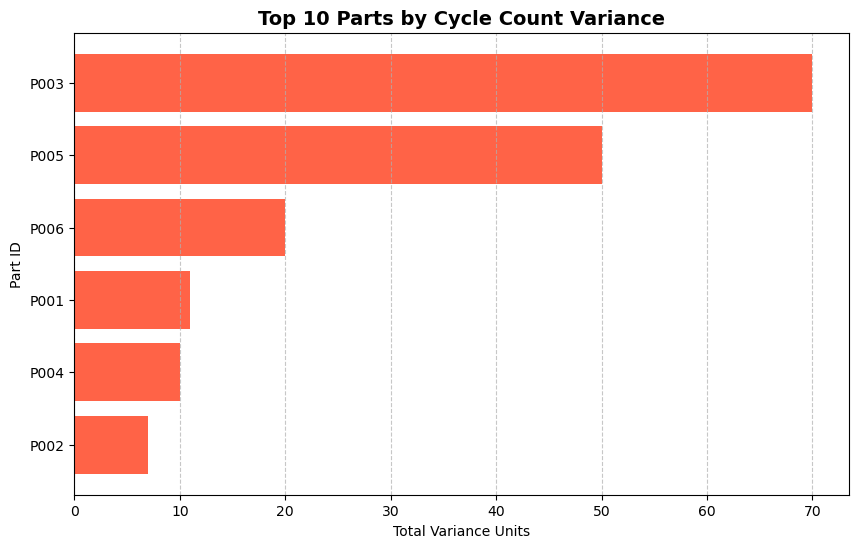

In [5]:
# We already have 'result' from your query
plt.figure(figsize=(10,6))
plt.barh(result['part_id'], result['total_variance'], color='tomato') # barh = horizontal bar
plt.gca().invert_yaxis() # puts biggest on top
plt.title('Top 10 Parts by Cycle Count Variance', fontsize=14, fontweight='bold')
plt.xlabel('Total Variance Units')
plt.ylabel('Part ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

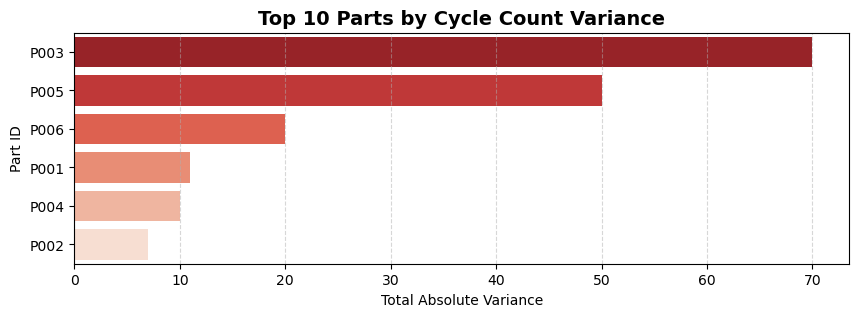

In [6]:
plt.figure(figsize=(10,3))
sns.barplot(data=result, x='total_variance', y='part_id', hue='part_id', palette='Reds_r', legend=False)

plt.title('Top 10 Parts by Cycle Count Variance', fontsize=14, fontweight='bold')
plt.xlabel('Total Absolute Variance')
plt.ylabel('Part ID')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [7]:
# Load + SQL same as before
df = pd.read_csv("CycleCount_Project.csv")
conn = sqlite3.connect(':memory:')
df.to_sql('Counts', conn, index=False)

# NEW QUERY with ALERT
query = """
SELECT 
    part_id,
    part_name,
    bin_location,
    SUM(ABS(counted_qty - system_qty)) as total_variance,
    CASE 
        WHEN SUM(ABS(counted_qty - system_qty)) > 50 THEN 'URGENT COUNT'
        WHEN SUM(ABS(counted_qty - system_qty)) > 20 THEN 'High Priority'
        ELSE 'Normal'
    END as alert_level
FROM Counts 
GROUP BY part_id, part_name, bin_location
ORDER BY total_variance DESC 
"""
result = pd.read_sql(query, conn)

# Filter to just urgent ones for the supervisor
urgent_list = result[result['alert_level'] == 'URGENT COUNT']
print("=== SUPERVISOR PRIORITY LIST ===")
print(urgent_list)

# Export to Excel for the warehouse floor
urgent_list.to_excel("Priority_Count_List.xlsx", index=False)

=== SUPERVISOR PRIORITY LIST ===
  part_id    part_name bin_location  total_variance   alert_level
0    P003  Washer 10mm      A-01-03              70  URGENT COUNT


##
**This flags anything with variance > 50 so the supervisor knows what to count TODAY.**